# Group Tournament Comparison - Connect-4 Agents

This notebook compares the group's agents using your updated structure:

```text
tournament/
├── connect4/
├── group_results/
├── groups/
│   ├── Group A Santiago/
│   │   └── policy.py
│   ├── Group B Ricardo/
│   │   └── policy.py
│   └── Group C Luis/
│       └── policy.py
├── main.py
└── tournament.py
```

It compares:

- **Group A Santiago**: `MinimaxAlphaBeta`
- **Group B Ricardo**: `MCTSAgent`
- **Group C Luis**: `LuisAgent`
- **RandomPolicy**: baseline

The goal is to decide which agent should be selected for the final tournament based on win rate, performance by color, illegal actions, head-to-head results, and computational cost.


## 1. Setup

In [14]:

import importlib.util
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROWS = 6
COLS = 7

# Start with 10 or 20 because MCTS can be slow.
# For final evidence, increase to 50 if it runs in a reasonable time.
GAMES_PER_COLOR = 20

cwd = Path.cwd()

if (cwd / "connect4").exists() and (cwd / "groups").exists():
    TOURNAMENT_ROOT = cwd
elif (cwd.parent / "connect4").exists() and (cwd.parent / "groups").exists():
    TOURNAMENT_ROOT = cwd.parent
elif (cwd / "tournament" / "connect4").exists() and (cwd / "tournament" / "groups").exists():
    TOURNAMENT_ROOT = cwd / "tournament"
else:
    raise RuntimeError(
        "Could not find the tournament folder. Run this notebook from tournament/ "
        "or from the repository root."
    )

OUTPUT_DIR = TOURNAMENT_ROOT / "group_results"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Current folder:", cwd)
print("Tournament root:", TOURNAMENT_ROOT)
print("Output folder:", OUTPUT_DIR)


Current folder: c:\Users\cylde\OneDrive\Documents\Repo\Ai project\AiProyectoLRS\tournament
Tournament root: c:\Users\cylde\OneDrive\Documents\Repo\Ai project\AiProyectoLRS\tournament
Output folder: c:\Users\cylde\OneDrive\Documents\Repo\Ai project\AiProyectoLRS\tournament\group_results


## 2. Load agents from the updated folders

In [15]:

def load_class_from_file(file_path: Path, class_name: str, module_name: str):
    """
    Loads a class from a specific .py file.
    This avoids problems with folder names that contain spaces.
    """
    file_path = Path(file_path).resolve()

    if not file_path.exists():
        raise FileNotFoundError(f"Could not find file: {file_path}")

    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    if not hasattr(module, class_name):
        available = [name for name in dir(module) if not name.startswith("_")]
        raise AttributeError(
            f"File {file_path} does not contain class {class_name}.\n"
            f"Available public names: {available}\n"
            f"Check the class name inside policy.py."
        )

    return getattr(module, class_name)


group_a_path = TOURNAMENT_ROOT / "groups" / "Group A Santiago" / "policy.py"
group_b_path = TOURNAMENT_ROOT / "groups" / "Group B Ricardo" / "policy.py"
group_c_luis_path = TOURNAMENT_ROOT / "groups" / "Group C Luis" / "policy.py"

MinimaxAlphaBeta = load_class_from_file(group_a_path, "MinimaxAlphaBeta", "group_a_santiago_policy")
MCTSAgent = load_class_from_file(group_b_path, "MCTSAgent", "group_b_ricardo_policy")
LuisAgent = load_class_from_file(group_c_luis_path, "LuisAgent", "group_c_luis_policy")

print("Loaded Group A Santiago:", MinimaxAlphaBeta)
print("Loaded Group B Ricardo:", MCTSAgent)
print("Loaded Group C Luis:", LuisAgent)


Loaded Group A Santiago: <class 'group_a_santiago_policy.MinimaxAlphaBeta'>
Loaded Group B Ricardo: <class 'group_b_ricardo_policy.MCTSAgent'>
Loaded Group C Luis: <class 'group_c_luis_policy.LuisAgent'>


## 3. Connect-4 helper functions

In [16]:

def valid_moves(board: np.ndarray) -> list[int]:
    return [c for c in range(COLS) if board[0, c] == 0]


def drop_piece(board: np.ndarray, col: int, player: int) -> np.ndarray:
    new_board = board.copy()

    for row in range(ROWS - 1, -1, -1):
        if new_board[row, col] == 0:
            new_board[row, col] = player
            return new_board

    return new_board


def winner(board: np.ndarray) -> int:
    """
    Returns:
        -1 if red wins
         1 if yellow wins
         0 if no winner
    """
    for r in range(ROWS):
        for c in range(COLS):
            piece = board[r, c]

            if piece == 0:
                continue

            if c + 3 < COLS and all(board[r, c + i] == piece for i in range(4)):
                return int(piece)

            if r + 3 < ROWS and all(board[r + i, c] == piece for i in range(4)):
                return int(piece)

            if r + 3 < ROWS and c + 3 < COLS:
                if all(board[r + i, c + i] == piece for i in range(4)):
                    return int(piece)

            if r + 3 < ROWS and c - 3 >= 0:
                if all(board[r + i, c - i] == piece for i in range(4)):
                    return int(piece)

    return 0


def safe_mount(agent):
    """
    Supports agents with different mount signatures:
    - mount()
    - mount(timeout)
    - no mount method
    """
    if hasattr(agent, "mount"):
        try:
            agent.mount()
        except TypeError:
            agent.mount(None)


class RandomPolicy:
    """Baseline random policy."""

    def __init__(self):
        self.rng = random.Random()

    def mount(self):
        pass

    def act(self, board: np.ndarray) -> int:
        moves = valid_moves(board)
        return int(self.rng.choice(moves))


## 4. Game execution functions

In [17]:

def play_game(red_agent, yellow_agent, max_turns: int = 42):
    board = np.zeros((ROWS, COLS), dtype=int)

    safe_mount(red_agent)
    safe_mount(yellow_agent)

    current_player = -1
    red_time = 0.0
    yellow_time = 0.0

    for turn in range(1, max_turns + 1):
        if current_player == -1:
            agent = red_agent
            start = time.time()
            action = agent.act(board.copy())
            red_time += time.time() - start
        else:
            agent = yellow_agent
            start = time.time()
            action = agent.act(board.copy())
            yellow_time += time.time() - start

        moves = valid_moves(board)

        if action not in moves:
            return {
                "winner": 1 if current_player == -1 else -1,
                "illegal_by": "red" if current_player == -1 else "yellow",
                "red_time": red_time,
                "yellow_time": yellow_time,
                "turns": turn,
            }

        board = drop_piece(board, action, current_player)

        w = winner(board)
        if w != 0:
            return {
                "winner": w,
                "illegal_by": None,
                "red_time": red_time,
                "yellow_time": yellow_time,
                "turns": turn,
            }

        current_player *= -1

    return {
        "winner": 0,
        "illegal_by": None,
        "red_time": red_time,
        "yellow_time": yellow_time,
        "turns": max_turns,
    }


def evaluate_pair(name_a, class_a, name_b, class_b, games_per_color: int):
    rows = []

    for game_id in range(games_per_color):
        result = play_game(class_a(), class_b())

        rows.append({
            "matchup": f"{name_a} vs {name_b}",
            "game_id": game_id + 1,
            "red_agent": name_a,
            "yellow_agent": name_b,
            "winner_value": result["winner"],
            "winner_name": name_a if result["winner"] == -1 else name_b if result["winner"] == 1 else "Draw",
            "illegal_by": result["illegal_by"],
            "red_time": result["red_time"],
            "yellow_time": result["yellow_time"],
            "turns": result["turns"],
        })

    for game_id in range(games_per_color):
        result = play_game(class_b(), class_a())

        rows.append({
            "matchup": f"{name_b} vs {name_a}",
            "game_id": game_id + 1,
            "red_agent": name_b,
            "yellow_agent": name_a,
            "winner_value": result["winner"],
            "winner_name": name_b if result["winner"] == -1 else name_a if result["winner"] == 1 else "Draw",
            "illegal_by": result["illegal_by"],
            "red_time": result["red_time"],
            "yellow_time": result["yellow_time"],
            "turns": result["turns"],
        })

    return rows


## 5. Run the round-robin tournament

In [ ]:

agents = {
    "Group A Santiago - MinimaxAlphaBeta": MinimaxAlphaBeta,
    "Group B Ricardo - MCTS_UCB1": MCTSAgent,
    "Group C Luis - TacticalExpectimax": LuisAgent,
    "RandomPolicy": RandomPolicy,
}

all_rows = []
agent_items = list(agents.items())

for i in range(len(agent_items)):
    for j in range(i + 1, len(agent_items)):
        name_a, class_a = agent_items[i]
        name_b, class_b = agent_items[j]

        print(f"Running: {name_a} vs {name_b}")
        all_rows.extend(evaluate_pair(name_a, class_a, name_b, class_b, GAMES_PER_COLOR))

raw_df = pd.DataFrame(all_rows)
raw_df.head()


Running: Group A Santiago - MinimaxAlphaBeta vs Group B Ricardo - MCTS_UCB1


## 6. Summary table

In [ ]:

def summarize_results(df: pd.DataFrame, agent_names: list[str]) -> pd.DataFrame:
    summary = []

    for agent in agent_names:
        games = df[(df["red_agent"] == agent) | (df["yellow_agent"] == agent)]

        wins = games[games["winner_name"] == agent]
        draws = games[games["winner_name"] == "Draw"]
        losses = len(games) - len(wins) - len(draws)

        red_games = games[games["red_agent"] == agent]
        yellow_games = games[games["yellow_agent"] == agent]

        red_wins = red_games[red_games["winner_name"] == agent]
        yellow_wins = yellow_games[yellow_games["winner_name"] == agent]

        illegal_moves = len(games[
            ((games["red_agent"] == agent) & (games["illegal_by"] == "red")) |
            ((games["yellow_agent"] == agent) & (games["illegal_by"] == "yellow"))
        ])

        avg_time_as_red = red_games["red_time"].mean() if len(red_games) else 0
        avg_time_as_yellow = yellow_games["yellow_time"].mean() if len(yellow_games) else 0

        summary.append({
            "agent": agent,
            "games": len(games),
            "wins": len(wins),
            "draws": len(draws),
            "losses": losses,
            "win_rate": 100 * len(wins) / len(games) if len(games) else 0,
            "red_win_rate": 100 * len(red_wins) / len(red_games) if len(red_games) else 0,
            "yellow_win_rate": 100 * len(yellow_wins) / len(yellow_games) if len(yellow_games) else 0,
            "illegal_moves": illegal_moves,
            "avg_time_as_red": avg_time_as_red,
            "avg_time_as_yellow": avg_time_as_yellow,
            "avg_time_total": (avg_time_as_red + avg_time_as_yellow) / 2,
        })

    return pd.DataFrame(summary).sort_values("win_rate", ascending=False).reset_index(drop=True)


summary_df = summarize_results(raw_df, list(agents.keys()))
summary_df


,agent,games,wins,draws,losses,win_rate,red_win_rate,yellow_win_rate,illegal_moves,avg_time_as_red,avg_time_as_yellow,avg_time_total
0,Group A Santiago - MinimaxAlphaBeta,120,120,0,0,100.000000,100.000000,100.000000,0,1.430089,2.715588,2.072838
1,Group C Luis - TacticalExpectimax,120,80,0,40,66.666667,66.666667,66.666667,0,4.031909,4.489479,4.260694
2,Group B Ricardo - MCTS_UCB1,120,31,0,89,25.833333,23.333333,28.333333,0,15.793021,11.230639,13.511830
3,RandomPolicy,120,9,0,111,7.500000,5.000000,10.000000,0,0.000041,0.000038,0.000039


In [ ]:

raw_path = OUTPUT_DIR / "group_tournament_raw.csv"
summary_path = OUTPUT_DIR / "group_tournament_summary.csv"

raw_df.to_csv(raw_path, index=False)
summary_df.to_csv(summary_path, index=False)

print("Saved raw results to:", raw_path)
print("Saved summary to:", summary_path)


Saved raw results to: c:\Users\cylde\OneDrive\Documents\Repo\Ai project\AiProyectoLRS\tournament\group_results\group_tournament_raw.csv
Saved summary to: c:\Users\cylde\OneDrive\Documents\Repo\Ai project\AiProyectoLRS\tournament\group_results\group_tournament_summary.csv


## 7. Graphs for group presentation

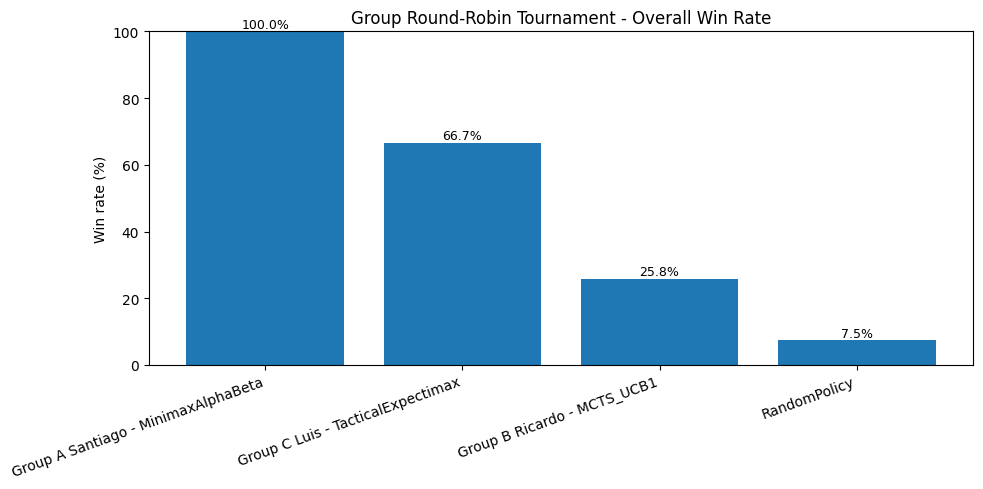

In [ ]:

plt.figure(figsize=(10, 5))
bars = plt.bar(summary_df["agent"], summary_df["win_rate"])

plt.ylabel("Win rate (%)")
plt.title("Group Round-Robin Tournament - Overall Win Rate")
plt.ylim(0, 100)
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, summary_df["win_rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "group_overall_win_rate.png", dpi=200)
plt.show()


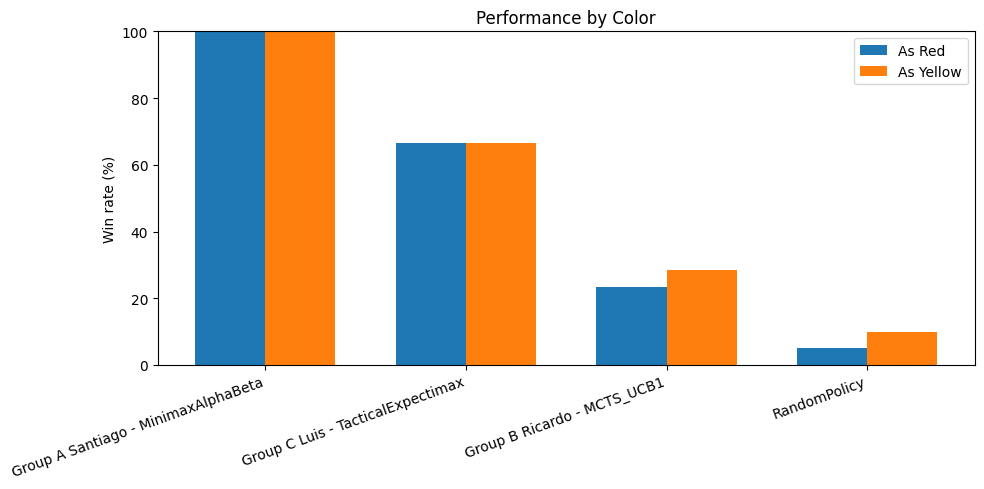

In [ ]:

x = np.arange(len(summary_df["agent"]))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, summary_df["red_win_rate"], width, label="As Red")
plt.bar(x + width / 2, summary_df["yellow_win_rate"], width, label="As Yellow")

plt.ylabel("Win rate (%)")
plt.title("Performance by Color")
plt.ylim(0, 100)
plt.xticks(x, summary_df["agent"], rotation=20, ha="right")
plt.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "group_win_rate_by_color.png", dpi=200)
plt.show()


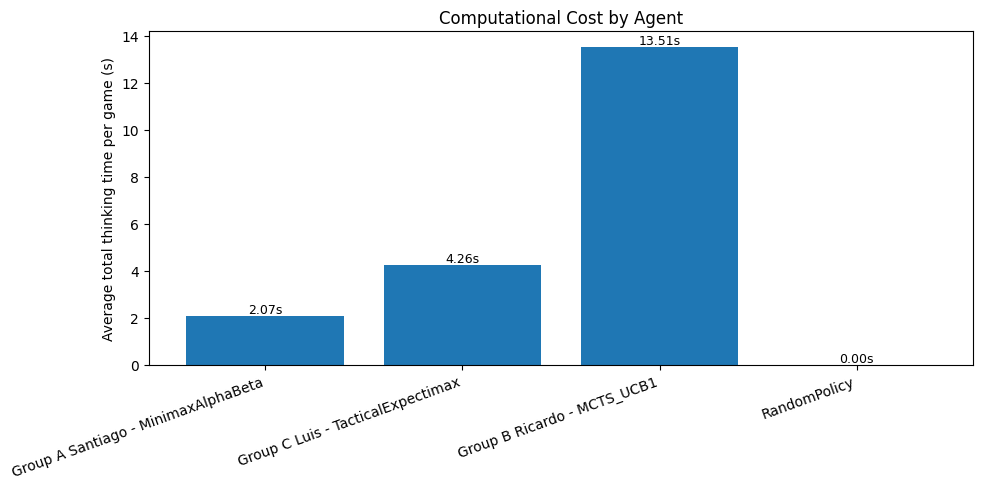

In [ ]:

plt.figure(figsize=(10, 5))
bars = plt.bar(summary_df["agent"], summary_df["avg_time_total"])

plt.ylabel("Average total thinking time per game (s)")
plt.title("Computational Cost by Agent")
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, summary_df["avg_time_total"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}s",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "group_average_time.png", dpi=200)
plt.show()


## 8. Head-to-head matrix

In [ ]:

agent_names = list(agents.keys())

matrix = pd.DataFrame(0, index=agent_names, columns=agent_names)

for _, row in raw_df.iterrows():
    winner_name = row["winner_name"]

    if winner_name == "Draw":
        continue

    red_agent = row["red_agent"]
    yellow_agent = row["yellow_agent"]
    loser = yellow_agent if winner_name == red_agent else red_agent

    matrix.loc[winner_name, loser] += 1

matrix


,Group A Santiago - MinimaxAlphaBeta,Group B Ricardo - MCTS_UCB1,Group C Luis - TacticalExpectimax,RandomPolicy
Group A Santiago - MinimaxAlphaBeta,0,40,40,40
Group B Ricardo - MCTS_UCB1,0,0,0,31
Group C Luis - TacticalExpectimax,0,40,0,40
RandomPolicy,0,9,0,0


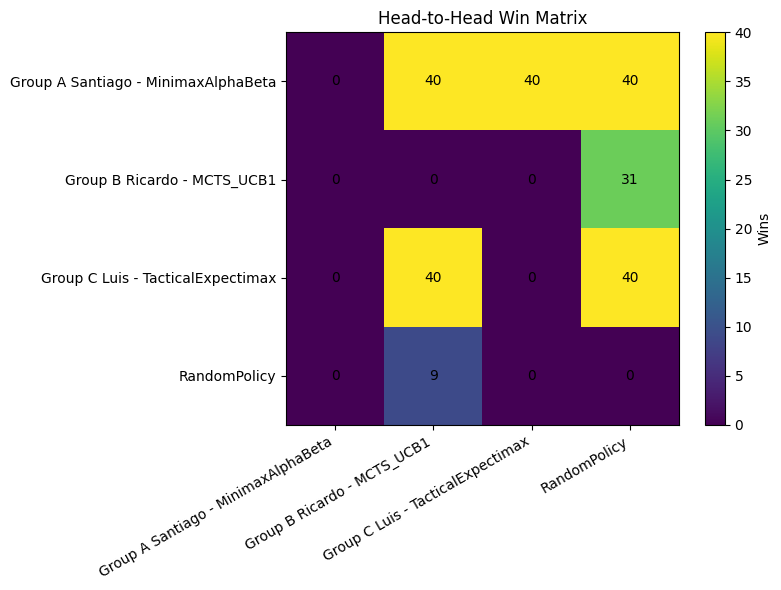

In [ ]:

plt.figure(figsize=(8, 6))
plt.imshow(matrix.values)

plt.xticks(range(len(agent_names)), agent_names, rotation=30, ha="right")
plt.yticks(range(len(agent_names)), agent_names)
plt.colorbar(label="Wins")

for i in range(len(agent_names)):
    for j in range(len(agent_names)):
        plt.text(j, i, matrix.values[i, j], ha="center", va="center")

plt.title("Head-to-Head Win Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "group_head_to_head_matrix.png", dpi=200)
plt.show()


## 9. Decision guide

A strong final tournament agent should have:

1. High overall win rate.
2. Good performance as both red and yellow.
3. Zero illegal moves.
4. Reasonable computational cost.
5. Stable results across matchups.

Recommended rule:

- Select the highest win-rate agent if it is not too slow.
- If two agents are close, choose the one with stronger yellow performance.
- If an agent is strong but too slow or unstable, choose the more reliable one.


In [ ]:

best_by_win_rate = summary_df.iloc[0]

print("Recommended agent based on highest overall win rate:")
print(best_by_win_rate["agent"])
print()
print("Details:")
print(f"Win rate: {best_by_win_rate['win_rate']:.1f}%")
print(f"Red win rate: {best_by_win_rate['red_win_rate']:.1f}%")
print(f"Yellow win rate: {best_by_win_rate['yellow_win_rate']:.1f}%")
print(f"Illegal moves: {best_by_win_rate['illegal_moves']}")
print(f"Average time per game: {best_by_win_rate['avg_time_total']:.2f}s")


Recommended agent based on highest overall win rate:
Group A Santiago - MinimaxAlphaBeta

Details:
Win rate: 100.0%
Red win rate: 100.0%
Yellow win rate: 100.0%
Illegal moves: 0
Average time per game: 2.07s
